## INTRODUCTION

### Model Training

This notebook focuses on training a machine learning model to classify traffic levels as High or Low using the cleaned dataset. Logistic Regression is used for this task due to its simplicity and effectiveness for binary classification.

### Import Libraries

This section imports all necessary libraries for model training, evaluation, and data splitting.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Load Cleaned Dataset

This loads the preprocessed dataset that was prepared during the data cleaning stage.

In [3]:
df = pd.read_csv("../data/processed/cleaned_traffic_data.csv")

### Define Features and Target

This separates the dataset into input features (X) and the target variable (y).

In [4]:
X = df.drop(columns=['traffic_level'])
y = df['traffic_level']

### Split Data into Training and Testing Sets

This splits the dataset into training and testing sets to evaluate model performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling and Model Training

This scales the features using StandardScaler and trains the Logistic Regression model. Scaling is important because it ensures all features contribute equally to the model.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Make Predictions

This uses the trained model to make predictions on the test dataset.

In [7]:
y_pred = model.predict(X_test)

### Model Accuracy

This calculates the accuracy of the model, which shows how well it predicts traffic levels.

In [8]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.6572969608961726

### Confusion Matrix

This shows how well the model performs in terms of correct and incorrect classifications.

In [9]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[3428, 1355],
       [1949, 2909]])

### Classification Report

This provides detailed performance metrics including precision, recall, and F1-score.

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.72      0.67      4783
           1       0.68      0.60      0.64      4858

    accuracy                           0.66      9641
   macro avg       0.66      0.66      0.66      9641
weighted avg       0.66      0.66      0.66      9641



### Visualize Confusion Matrix

This visualizes the confusion matrix to make interpretation easier.

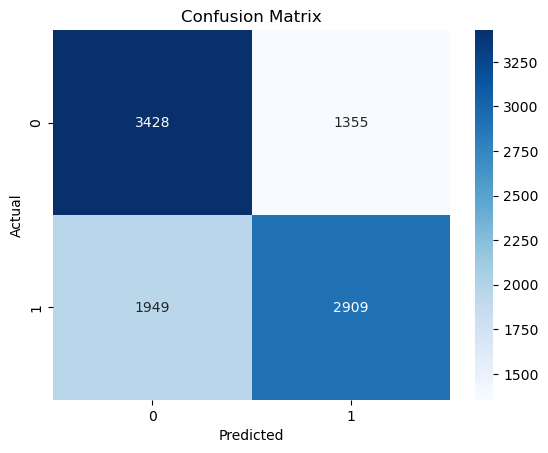

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Save Model and Scaler

This saves the trained model and scaler for use in the Streamlit application. The scaler is important to ensure new data is transformed in the same way as training data.

In [16]:
import os
import pickle

# Create folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save model
pickle.dump(model, open("../models/model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("../models/scaler.pkl", "wb"))

### Feature Names

This displays the feature columns used during training, which is important for ensuring consistency during prediction.

In [17]:
print(X.columns)

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week',
       'month', 'year', 'is_weekend', 'is_rush_hour', 'weather_main_Clouds',
       'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze',
       'weather_main_Mist', 'weather_main_Other', 'weather_main_Rain',
       'weather_main_Snow', 'weather_main_Thunderstorm'],
      dtype='object')


### Summary of Model Training Process

This notebook focused on building a Logistic Regression model to predict traffic levels based on processed features from weather and time-based data.

The dataset was first split into input features (X) and target variable (traffic_level), where the goal is to classify traffic as either High (1) or Low (0). The data was then split into training and testing sets to evaluate model performance on unseen data.

Feature scaling was applied using StandardScaler to ensure all features contribute equally to the model training process. This step is important for Logistic Regression because it improves convergence and stability.

### Model Performance Evaluation

The model was evaluated using several metrics:

- **Accuracy Score:** Measures overall correctness of predictions.
- **Confusion Matrix:** Shows the breakdown of correct and incorrect predictions.
- **Classification Report:** Provides precision, recall, and F1-score for each class.

### Confusion Matrix Explanation

The confusion matrix consists of four key outcomes:

- **True Positives (TP):** Correctly predicted High Traffic cases.
- **True Negatives (TN):** Correctly predicted Low Traffic cases.
- **False Positives (FP):** Low traffic incorrectly predicted as High traffic.
- **False Negatives (FN):** High traffic incorrectly predicted as Low traffic.

In this project:
- A **False Positive** means the system wrongly warns of traffic when it is actually low.
- A **False Negative** is more critical because it fails to predict actual high traffic, which could mislead users.

### Final Insight

The model achieved a baseline performance suitable for a simple predictive system. While Logistic Regression is lightweight and interpretable, future improvements could include more advanced models such as Random Forest or Gradient Boosting for higher accuracy.

The trained model and scaler were saved for deployment in the Streamlit application, enabling real-time traffic prediction based on user input.